# Compare Outlier Definitions for Holdout Wells

This notebook compares three outlier definitions on per-well error profiles:
1. Top-10% wells by RMSE
2. IQR rule: RMSE > Q3 + 1.5*IQR
3. Absolute threshold: RMSE > tau (default tau=5.0)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
CSV = ROOT / '../../reports/kriging/outlier_analysis/TFT_in52_out16_ep50_bs4096_stat1_seed40_full_merged__predobstrain/outlier_well_profile.csv'
df = pd.read_csv(CSV)
df = df[['id','rmse','mae','bias','n_obs_full','gws_iqr_full']].copy()
df = df.dropna(subset=['rmse']).sort_values('rmse').reset_index(drop=True)
print(f'wells: {len(df)}')

wells: 199


In [3]:
# Definition A: Top 10%
top_frac = 0.10
n_top = max(1, int(np.ceil(len(df) * top_frac)))
top_ids = set(df.nlargest(n_top, 'rmse')['id'])

# Definition B: IQR rule
q1 = df['rmse'].quantile(0.25)
q3 = df['rmse'].quantile(0.75)
iqr = q3 - q1
iqr_thr = q3 + 1.5 * iqr
iqr_ids = set(df.loc[df['rmse'] > iqr_thr, 'id'])

# Definition C: Absolute threshold
tau = 5.0
abs_ids = set(df.loc[df['rmse'] > tau, 'id'])

df['out_top10pct'] = df['id'].isin(top_ids)
df['out_iqr'] = df['id'].isin(iqr_ids)
df['out_abs_tau'] = df['id'].isin(abs_ids)

print('thresholds:')
print(f'  IQR threshold: {iqr_thr:.3f}')
print(f'  Absolute threshold (tau): {tau:.3f}')
print('counts:')
print(f"  top10pct: {df['out_top10pct'].sum()}")
print(f"  iqr:      {df['out_iqr'].sum()}")
print(f"  abs_tau:  {df['out_abs_tau'].sum()}")

thresholds:
  IQR threshold: 5.323
  Absolute threshold (tau): 5.000
counts:
  top10pct: 20
  iqr:      23
  abs_tau:  25


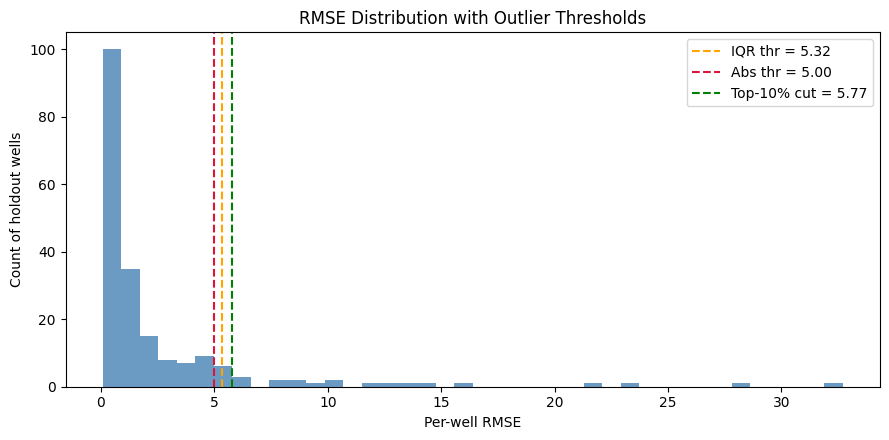

In [6]:
# Visual diagnostics
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df['rmse'], bins=40, color='steelblue', alpha=0.8)
ax.axvline(iqr_thr, color='orange', linestyle='--', label=f'IQR thr = {iqr_thr:.2f}')
ax.axvline(tau, color='crimson', linestyle='--', label=f'Abs thr = {tau:.2f}')
top_cut = df['rmse'].nlargest(n_top).min()
ax.axvline(top_cut, color='green', linestyle='--', label=f'Top-10% cut = {top_cut:.2f}')
ax.set_title('RMSE Distribution with Outlier Thresholds')
ax.set_xlabel('Per-well RMSE')
ax.set_ylabel('Count of holdout wells')
ax.legend()
plt.tight_layout()
plt.show()